## Sentiment Analysis

In this exercise we use the IMDb-dataset, which we will use to perform a sentiment analysis. The code below assumes that the data is placed in the same folder as this notebook. We see that the reviews are loaded as a pandas dataframe, and print the beginning of the first few reviews.

In [1]:
import numpy as np
import pandas as pd

reviews = pd.read_csv('reviews.txt', header=None)
labels = pd.read_csv('labels.txt', header=None)
Y = (labels=='positive').astype(np.int_)

print(type(reviews))
print(reviews.head())

<class 'pandas.core.frame.DataFrame'>
                                                   0
0  bromwell high is a cartoon comedy . it ran at ...
1  story of a man who has unnatural feelings for ...
2  homelessness  or houselessness as george carli...
3  airport    starts as a brand new luxury    pla...
4  brilliant over  acting by lesley ann warren . ...


**(a)** Split the reviews and labels in test, train and validation sets. The train and validation sets will be used to train your model and tune hyperparameters, the test set will be saved for testing. Use the `CountVectorizer` from `sklearn.feature_extraction.text` to create a Bag-of-Words representation of the reviews. Only use the 10,000 most frequent words (use the `max_features`-parameter of `CountVectorizer`).

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
 
reviews.columns = ['review']

X_train, X_test, y_train, y_test = train_test_split(reviews['review'], Y, test_size=0.2, random_state=42)

bag_of_words = CountVectorizer(max_features=10*1000)
bag_of_words.fit(X_train)

bag_of_words.vocabulary_

{'the': 8960,
 'idea': 4386,
 'of': 6179,
 'making': 5417,
 'miniseries': 5705,
 'about': 16,
 'berlin': 841,
 'seemed': 7840,
 'to': 9087,
 'me': 5562,
 'as': 506,
 'one': 6221,
 'more': 5817,
 'interesting': 4634,
 'german': 3742,
 'post': 6762,
 'war': 9666,
 'movies': 5862,
 'it': 4718,
 'is': 4705,
 'theme': 8970,
 'that': 8957,
 'has': 4081,
 'not': 6090,
 'been': 781,
 'explored': 3171,
 'much': 5871,
 'yet': 9964,
 'however': 4325,
 'makers': 5414,
 'this': 9003,
 'series': 7897,
 'stuffed': 8611,
 'with': 9854,
 'clichs': 1617,
 'starts': 8462,
 'already': 277,
 'dvd': 2765,
 'cover': 2018,
 'movie': 5861,
 'which': 9777,
 'direct': 2497,
 'copy': 1964,
 'pearl': 6489,
 'harbor': 4051,
 'br': 1049,
 'luise': 5345,
 'gets': 3749,
 'hear': 4118,
 'her': 4164,
 'husband': 4364,
 'who': 9787,
 'doctor': 2593,
 'died': 2467,
 'in': 4470,
 'russia': 7633,
 'and': 334,
 'after': 180,
 'she': 7979,
 'struggling': 8596,
 'survive': 8755,
 'finds': 3394,
 'job': 4802,
 'at': 554,
 'amer

**(b)** Explore the representation of the reviews. How is a single word represented? How about a whole review?

In [3]:
test_word = 'great'
test_sentence = 'This is a great movie'

test_word_vector = bag_of_words.transform([test_word])
print(f"Test word vector for '{test_word}':\n{test_word_vector}")

test_sentence_vector = bag_of_words.transform([test_sentence])
print(f"Test sentence vector for '{test_sentence}':\n{test_sentence_vector}")

Test word vector for 'great':
  (0, 3900)	1
Test sentence vector for 'This is a great movie':
  (0, 3900)	1
  (0, 4705)	1
  (0, 5861)	1
  (0, 9003)	1


**(c)** Train a neural network with a single hidden layer on the dataset, tuning the relevant hyperparameters to optimize accuracy. 

In [4]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
layer_input_dim = bag_of_words.vocabulary_.__len__()


hyper_layer_sizes = [10, 50,]
hyper_learning_rates = [0.001, 0.01,]
hyper_batch_sizes = [10, 50]

best_accuracy = 0
best_hyperparameters = None

for layer_size in hyper_layer_sizes:
    for learning_rate in hyper_learning_rates:
        for batch_size in hyper_batch_sizes:
            tf.random.set_seed(42)
            ann = tf.keras.Sequential([
                layers.Dense(layer_size, input_dim=layer_input_dim, activation="sigmoid"), 
                layers.Dense(1, activation="sigmoid")
            ])

            ann.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])
            print(ann.summary())
 
            history = ann.fit(bag_of_words.transform(X_train), y_train, epochs=10, batch_size=50, validation_split=0.2)
            if history.history['val_accuracy'][-1] > best_accuracy:
                best_accuracy = history.history['val_accuracy'][-1]
                best_hyperparameters = (layer_size, learning_rate, batch_size)
                print(f"New best hyperparameters: {best_hyperparameters} with accuracy: {best_accuracy}")


best_layer_size, best_learning_rate, best_batch_size = best_hyperparameters

print(f"Best hyperparameters: Layer size: {best_layer_size}, Learning rate: {best_learning_rate}, Batch size: {best_batch_size}")

# Train the final model with the best hyperparameters

tf.random.set_seed(42)
ann = tf.keras.Sequential([
    layers.Dense(best_layer_size, input_dim=layer_input_dim, activation="sigmoid"), 
    layers.Dense(1, activation="sigmoid")
])
ann.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=best_learning_rate), metrics=['accuracy'])
history = ann.fit(bag_of_words.transform(X_train), y_train, epochs=10, batch_size=best_batch_size, validation_split=0.2)




2025-04-17 17:44:08.753256: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-17 17:44:08.754017: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-17 17:44:08.757043: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-17 17:44:08.763076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744904648.773014   41338 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744904648.77

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │       100,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,021 (390.71 KB)

 Trainable params: 100,021 (390.71 KB)

...

 Trainable params: 500,101 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8174 - loss: 0.3966 - val_accuracy: 0.8863 - val_loss: 0.2728
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9410 - loss: 0.1494 - val_accuracy: 0.8755 - val_loss: 0.3254
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9758 - loss: 0.0752 - val_accuracy: 0.8698 - val_loss: 0.3785
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9778 - loss: 0.0657 - val_accuracy: 0.8730 - val_loss: 0.3631
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9735 - loss: 0.0765 - val_accuracy: 0.8763 - val_loss: 0.3634
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9822 - loss: 0.0520 - val_accuracy: 0.8777 - val_loss: 0.4185
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9871 - loss: 0.0376 - val_accuracy: 0.8633 - val_loss: 0.5146
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9946 - loss: 0.0232 - val_accurac

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7604 - loss: 0.5073 - val_accuracy: 0.8900 - val_loss: 0.2952
Epoch 2/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9187 - loss: 0.2315 - val_accuracy: 0.8915 - val_loss: 0.2795
Epoch 3/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9518 - loss: 0.1540 - val_accuracy: 0.8865 - val_loss: 0.2981
Epoch 4/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9704 - loss: 0.1090 - val_accuracy: 0.8805 - val_loss: 0.3347
Epoch 5/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9808 - loss: 0.0790 - val_accuracy: 0.8780 - val_loss: 0.3686
Epoch 6/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9881 - loss: 0.0578 - val_accuracy: 0.8773 - val_loss: 0.4093
Epoch 7/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9920 - loss: 0.0417 - val_accuracy: 0.8758 - val_loss: 0.4587
Epoch 8/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9952 - loss: 0.0303 - 

**(d)** Test your sentiment-classifier on the test set.

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      2492
           1       0.85      0.86      0.86      2508

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



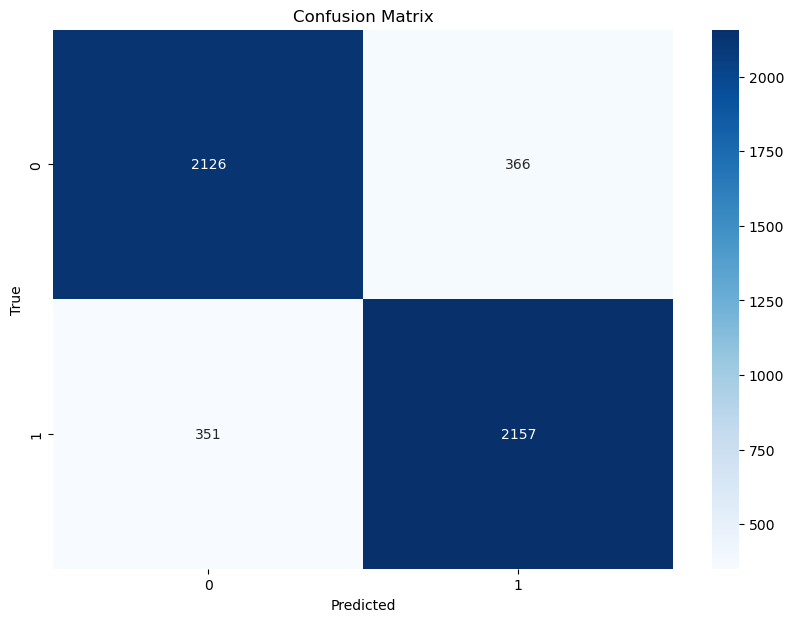

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


y_pred = ann.predict(bag_of_words.transform(X_test))
y_pred = (y_pred > 0.5).astype(np.int_)

cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


**(e)** Use the classifier to classify a few sentences you write yourselves. 

In [19]:
test_sentences = [
    'This is a great movie',
    'This is a bad movie',
    'I love this movie',
    'I hate this movie',
    'This movie is okay'
]


y_my_own_pred = ann.predict(bag_of_words.transform(test_sentences))
y_my_own_pred = (y_my_own_pred > 0.5).astype(np.int_)


for sentence, pred in zip(test_sentences, y_my_own_pred):
    print(f"Sentence: '{sentence}' - Prediction: {'positive' if pred == 1 else 'negative'}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Sentence: 'This is a great movie' - Prediction: positive
Sentence: 'This is a bad movie' - Prediction: negative
Sentence: 'I love this movie' - Prediction: positive
Sentence: 'I hate this movie' - Prediction: negative
Sentence: 'This movie is okay' - Prediction: negative
